# 03. Optimización de Modelos Espaciales y Validación Libre de Leakage (SUHI)

Este notebook implementa un marco de modelado científico para optimizar la predicción de la Isla de Calor Urbana Superficial (`suhi_c`) en Monterrey.

### Objetivos Principales:
1. **Regla Estricta de Cero Leakage:** Evaluar modelos bajo validación cruzada espacial por bloques sin permitir fugas de información del target del test split.
2. **Experimento A (Predicción Absoluta):** Comparar Elastic Net, Ridge, Random Forest y XGBoost prediciendo el valor absoluto de `suhi_c`.
3. **Experimento B (Anomalía Local):** Evaluar si predecir la anomalía térmica local (restando un baseline aprendido únicamente en el fold de entrenamiento) mejora el desempeño y la estabilidad del R² espacial.
4. **Experimento C (Modelos de Extrapolación Híbridos):** Entrenar y probar modelos con mayor capacidad de extrapolación:
   * Regresión Ridge con características polinomiales de interacción.
   * Un modelo híbrido lineal + no lineal (Ridge + XGBoost sobre residuos) para capturar tendencias regionales absolutas y microclimas locales.
5. **Diagnóstico Espacial y Visualización:** Reportar métricas por fold, graficar boxplots de error, e identificar bloques geográficos problemáticos.


### ☁️ Control de Calidad Atmosférica: Máscara de Nubes Landsat 8 (QA_PIXEL)

Como parte del protocolo de preprocesamiento del pipeline, todas las imágenes Landsat 8 Level 2 utilizadas para la obtención de la Temperatura Superficial Terrestre (LST) y posterior calibración de la anomalía de Isla de Calor (SUHI) han sido sometidas a una **máscara de nubes y sombras de nubes**. 

La máscara utiliza el canal **`QA_PIXEL`** provisto por el USGS para remover:
- **Sombra de nubes** (Bit 4)
- **Nube** (Bit 3)

Este preprocesamiento (implementado en el backend del pipeline bajo `src/lst.py` y `src/temporal_analysis.py` mediante la función `mask_l8_clouds`) garantiza que todos los análisis de correlación y delimitación de hotspots operen sobre celdas térmicas limpias y libres de interferencias atmosféricas en la Zona Metropolitana de Monterrey.

In [ ]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Carga de Datos y Preprocesamiento de Cero Leakage

Cargamos el dataset enriquecido multiescala `malla_modelado_multiescala_mty.gpkg`, definimos las columnas predictoras y excluimos cualquier variable que cause fuga de datos (LST, targets alternativos o variables sociales).


In [2]:
gpkg_path = "../data/processed/malla_modelado_multiescala_mty.gpkg"
if not os.path.exists(gpkg_path):
    gpkg_path = "data/processed/malla_modelado_multiescala_mty.gpkg"

print(f"Cargando dataset multiescala desde: {gpkg_path}...")
gdf = gpd.read_file(gpkg_path)

# Definir target y exclusiones de leakage
target_col = 'suhi_c'
excluded_cols = [
    'cell_id', 'geometry', 'lst_day_c', 'lst_c', 'lst_night_c',
    'suhi_day_c', 'suhi_night_c', 'suhi_c', 'x_coord', 'y_coord',
    'spatial_block', 'distance_to_ternium_m'
]

# Columnas predictoras
predictor_cols = [col for col in gdf.columns if col not in excluded_cols and not col.endswith('_night_c') and not col.startswith('lst')]

# Limpieza de nulos (sin incluir spatial_block ya que no viene en el archivo)
cols_to_use = predictor_cols + [target_col, 'distance_to_ternium_m', 'x_coord', 'y_coord']
df_clean = gdf[cols_to_use].dropna().copy()

# Generar spatial_block en base a KMeans de coordenadas del dataset limpio
coords = df_clean[['x_coord', 'y_coord']].values
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean['spatial_block'] = kmeans.fit_predict(coords)

X = df_clean[predictor_cols]
y = df_clean[target_col]
groups = df_clean['spatial_block']

print(f"Características de entrada: {X.shape[1]}")
print(f"Celdas para modelar: {len(df_clean)}")


Cargando dataset multiescala desde: ../data/processed/malla_modelado_multiescala_mty.gpkg...


Características de entrada: 41
Celdas para modelar: 186087


## 2. Experimento A: Predicción Absoluta Honesta (Benchmark)

Evaluamos los modelos entrenados para predecir el valor absoluto de `suhi_c` bajo validación cruzada espacial de 5 bloques (`GroupKFold`).

Modelos evaluados:
* **Elastic Net** (regularización L1/L2)
* **Ridge Regression** (regularización L2)
* **Random Forest Regressor**
* **XGBoost Regressor**


In [3]:
# Definición de validación cruzada espacial
spatial_cv = GroupKFold(n_splits=5)

# Función de evaluación detallada que devuelve métricas por fold
def evaluate_cv_by_fold(model, X, y, cv, groups):
    maes, rmses, r2s = [], [], []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Entrenar y predecir
        model_fit = model.fit(X_train, y_train)
        preds = model_fit.predict(X_test)
        
        # Guardar métricas del fold
        maes.append(mean_absolute_error(y_test, preds))
        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        r2s.append(r2_score(y_test, preds))
        
    return maes, rmses, r2s


In [4]:
# Inicializar modelos base
models_a = {
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

# Almacenar resultados de todos los experimentos
results_dict = {}

for name, model in models_a.items():
    print(f"Evaluando {name} (Experimento A)...")
    maes, rmses, r2s = evaluate_cv_by_fold(model, X, y, spatial_cv, groups)
    results_dict[f"{name}_Abs"] = {
        'MAE': maes,
        'RMSE': rmses,
        'R2': r2s,
        'MAE_mean': np.mean(maes),
        'R2_mean': np.mean(r2s)
    }
    print(f" -> MAE Medio: {np.mean(maes):.3f}°C | R² Medio: {np.mean(r2s):.3f}")


Evaluando Elastic Net (Experimento A)...


 -> MAE Medio: 3.285°C | R² Medio: -0.542
Evaluando Ridge (Experimento A)...


 -> MAE Medio: 3.780°C | R² Medio: -1.066
Evaluando Random Forest (Experimento A)...


 -> MAE Medio: 2.853°C | R² Medio: -0.201
Evaluando XGBoost (Experimento A)...


 -> MAE Medio: 2.779°C | R² Medio: -0.145


## 3. Experimento B: Anomalía Local sin Leakage

### Metodología para evitar Target Leakage
Para predecir anomalías térmicas locales, redefinimos el target como:
$$	ext{suhi\_local\_anomaly}_i = 	ext{suhi\_c}_i - 	ext{baseline\_local}_i$$

Para garantizar que **no existe fuga de información** del conjunto de prueba:
1. **Clusters Físicos:** Agrupamos las celdas en 10 clases morfológicas usando KMeans sobre variables puramente independientes (`dw_built_pct`, `elevation`, `green_pct`, `distance_to_industry_osm_m`). Al no utilizar `suhi_c`, la asignación de clusters no tiene leakage.
2. **Cálculo de Baseline sin Leakage:** En cada fold de la validación cruzada, calculamos la temperatura media de cada cluster **exclusivamente usando los datos de entrenamiento** del fold:
   $$	ext{baseline\_local}[c] = 	ext{mean}(	ext{suhi\_c}_{	ext{train, cluster } c})$$
3. **Mapeo al Test Fold:** Para las celdas del conjunto de prueba, su baseline se define por la asignación de su cluster físico mapeada al valor promedio aprendido en el entrenamiento. El target real del test fold jamás es visto por el proceso de entrenamiento.
4. **Reconstrucción:** El modelo predice la anomalía. Las predicciones finales de SUHI absoluto se obtienen sumando la anomalía predicha y el baseline de prueba:
   $$\hat{y}_{	ext{test}} = \hat{a}_{	ext{test}} + 	ext{baseline\_local}_{	ext{test}}$$


In [5]:
# 1. Crear clusters físicos utilizando variables independientes
cluster_features = ['dw_built_pct', 'elevation', 'green_pct', 'distance_to_industry_osm_m']
kmeans_phys = KMeans(n_clusters=10, random_state=42, n_init=10)
df_clean['physical_cluster'] = kmeans_phys.fit_predict(df_clean[cluster_features])

# 2. Validación cruzada de anomalía local
def evaluate_local_anomaly_cv(model, X, y, cv, groups, df):
    maes, rmses, r2s = [], [], []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        # Dividir
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        df_train = df.iloc[train_idx]
        df_test = df.iloc[test_idx]
        
        # Calcular el baseline promedio por cluster físico EXCLUSIVAMENTE en el train split
        cluster_means = df_train.groupby('physical_cluster')[target_col].mean().to_dict()
        
        # Si un cluster no aparece en el train (muy raro), se le asigna la media global del train
        global_train_mean = y_train.mean()
        
        # Definir baselines para train y test
        baseline_train = df_train['physical_cluster'].map(cluster_means).fillna(global_train_mean).values
        baseline_test = df_test['physical_cluster'].map(cluster_means).fillna(global_train_mean).values
        
        # Crear target de anomalía
        y_train_anomaly = y_train - baseline_train
        
        # Entrenar modelo en la anomalía
        model_fit = model.fit(X_train, y_train_anomaly)
        
        # Predecir anomalía
        pred_anomaly = model_fit.predict(X_test)
        
        # Reconstruir SUHI absoluto sumando el baseline de prueba
        pred_absolute = pred_anomaly + baseline_test
        
        # Guardar métricas del fold evaluado sobre los valores absolutos reales
        maes.append(mean_absolute_error(y_test, pred_absolute))
        rmses.append(np.sqrt(mean_squared_error(y_test, pred_absolute)))
        r2s.append(r2_score(y_test, pred_absolute))
        
    return maes, rmses, r2s


In [6]:
# Evaluar Random Forest y XGBoost en Anomalía Local
models_b = {
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

for name, model in models_b.items():
    print(f"Evaluando {name} con Anomalía Local (Experimento B)...")
    maes, rmses, r2s = evaluate_local_anomaly_cv(model, X, y, spatial_cv, groups, df_clean)
    results_dict[f"{name}_Anomaly"] = {
        'MAE': maes,
        'RMSE': rmses,
        'R2': r2s,
        'MAE_mean': np.mean(maes),
        'R2_mean': np.mean(r2s)
    }
    print(f" -> MAE Medio: {np.mean(maes):.3f}°C | R² Medio: {np.mean(r2s):.3f}")


Evaluando Random Forest con Anomalía Local (Experimento B)...


 -> MAE Medio: 2.934°C | R² Medio: -0.256
Evaluando XGBoost con Anomalía Local (Experimento B)...


 -> MAE Medio: 2.852°C | R² Medio: -0.223


## 4. Experimento C: Modelos con Mejor Capacidad de Extrapolación

Los modelos basados en árboles no pueden extrapolar tendencias absolutas (como la disminución de temperatura con la altitud fuera del rango visto en el entrenamiento). 

Para mitigar esta limitación de extrapolación espacial, evaluamos dos alternativas:
1. **Regresión Ridge con interacciones polinomiales moderadas:** Generamos interacciones de segundo orden sobre un subconjunto de características clave (`dw_built_3km`, `elevation`, `green_pct_spatial_lag`) y aplicamos regularización L2.
2. **Modelo Híbrido Lineal-No Lineal (Residual Stacking):**
   * Ajustamos una regresión lineal (Ridge) sobre la tendencia general de altitud y concreto.
   * Calculamos los residuos lineales del conjunto de entrenamiento: $r = y - \hat{y}_{	ext{linear}}$.
   * Entrenamos un XGBoost Regressor para predecir los residuos.
   * La predicción final reconstruida en el test fold es la suma del componente Ridge y el XGBoost sobre residuos.


In [7]:
# 1. Regresión Ridge Polinomial (Interacciones)
# Seleccionar un conjunto clave de variables predictoras para evitar explosión de dimensiones
poly_features = ['elevation', 'dw_built_3000m', 'green_pct_spatial_lag', 'distance_to_industry_osm_m']
X_poly_base = X[poly_features]

poly_pipeline = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True),
    Ridge(alpha=10.0)
)

print("Evaluando Ridge Polinomial (Experimento C)...")
maes, rmses, r2s = evaluate_cv_by_fold(poly_pipeline, X_poly_base, y, spatial_cv, groups)
results_dict["Ridge_Poly"] = {
    'MAE': maes,
    'RMSE': rmses,
    'R2': r2s,
    'MAE_mean': np.mean(maes),
    'R2_mean': np.mean(r2s)
}
print(f" -> MAE Medio: {np.mean(maes):.3f}°C | R² Medio: {np.mean(r2s):.3f}")


Evaluando Ridge Polinomial (Experimento C)...


 -> MAE Medio: 3.011°C | R² Medio: -0.188


In [8]:
# 2. Modelo Híbrido (Ridge + XGBoost en Residuos)
def evaluate_hybrid_cv(X, y, cv, groups):
    maes, rmses, r2s = [], [], []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Paso 1: Ajustar modelo Ridge global
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_train)
        X_te_scaled = scaler.transform(X_test)
        
        ridge = Ridge(alpha=10.0)
        ridge.fit(X_tr_scaled, y_train)
        
        # Predicción Ridge
        pred_ridge_tr = ridge.predict(X_tr_scaled)
        pred_ridge_te = ridge.predict(X_te_scaled)
        
        # Paso 2: Calcular residuos en entrenamiento
        residuals_train = y_train - pred_ridge_tr
        
        # Paso 3: Entrenar XGBoost sobre los residuos
        xgb_res = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
        xgb_res.fit(X_train, residuals_train)
        
        # Predecir residuos
        pred_res_te = xgb_res.predict(X_test)
        
        # Paso 4: Reconstruir predicción final
        pred_final = pred_ridge_te + pred_res_te
        
        # Guardar métricas del fold
        maes.append(mean_absolute_error(y_test, pred_final))
        rmses.append(np.sqrt(mean_squared_error(y_test, pred_final)))
        r2s.append(r2_score(y_test, pred_final))
        
    return maes, rmses, r2s


In [9]:
print("Evaluando Modelo Híbrido (Ridge + XGBoost en Residuos)...")
maes, rmses, r2s = evaluate_hybrid_cv(X, y, spatial_cv, groups)
results_dict["Hybrid_Ridge_XGB"] = {
    'MAE': maes,
    'RMSE': rmses,
    'R2': r2s,
    'MAE_mean': np.mean(maes),
    'R2_mean': np.mean(r2s)
}
print(f" -> MAE Medio: {np.mean(maes):.3f}°C | R² Medio: {np.mean(r2s):.3f}")


Evaluando Modelo Híbrido (Ridge + XGBoost en Residuos)...


 -> MAE Medio: 3.591°C | R² Medio: -0.948


## 5. Diagnóstico y Visualización

Analizamos el comportamiento de los diferentes enfoques comparando la distribución de errores (MAE) y el coeficiente de determinación ($R^2$) en cada bloque espacial.


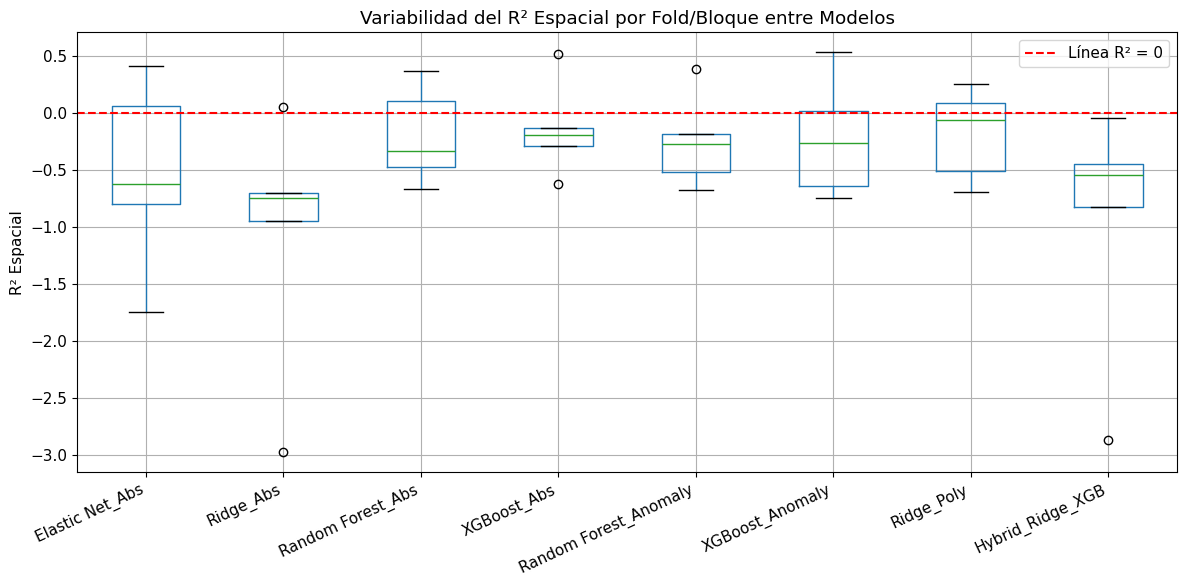

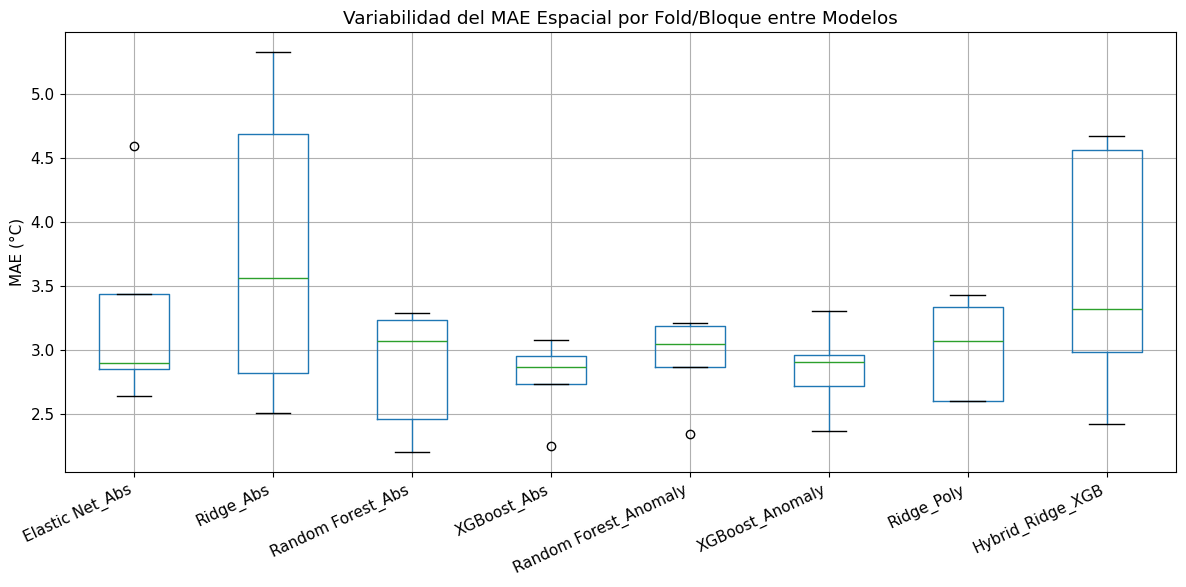

In [10]:
# Crear DataFrames para graficar la variabilidad entre bloques
r2_data = {}
mae_data = {}

for model_name, metrics in results_dict.items():
    r2_data[model_name] = metrics['R2']
    mae_data[model_name] = metrics['MAE']

df_r2_folds = pd.DataFrame(r2_data)
df_mae_folds = pd.DataFrame(mae_data)

# Graficar Boxplot de R2 Espacial por modelo
plt.figure(figsize=(12, 6))
df_r2_folds.boxplot()
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label="Línea R² = 0")
plt.title("Variabilidad del R² Espacial por Fold/Bloque entre Modelos")
plt.ylabel("R² Espacial")
plt.xticks(rotation=25, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/03/model_spatial_r2_boxplot.png", dpi=300)
plt.show()

# Graficar Boxplot de MAE Espacial por modelo
plt.figure(figsize=(12, 6))
df_mae_folds.boxplot()
plt.title("Variabilidad del MAE Espacial por Fold/Bloque entre Modelos")
plt.ylabel("MAE (°C)")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig("../outputs/03/model_spatial_mae_boxplot.png", dpi=300)
plt.show()


### Diagnóstico Geográfico de Bloques Frecuentemente Fallidos

Analizamos qué bloque geográfico presenta el peor rendimiento promedio bajo validación cruzada y documentamos las hipótesis físicas de este colapso.


In [11]:
# Identificar métricas del peor bloque para el modelo XGBoost Absoluto
xgb_abs_r2 = results_dict['XGBoost_Abs']['R2']
xgb_abs_mae = results_dict['XGBoost_Abs']['MAE']

# Mapear los bloques KMeans en un dataframe resumido
block_stats = []
for block_id in range(5):
    # Celdas en este bloque
    subset = df_clean[df_clean['spatial_block'] == block_id]
    block_stats.append({
        'Bloque': block_id,
        'N_Celdas': len(subset),
        'Elevacion_Media (m)': subset['elevation'].mean(),
        'Built_Media (%)': subset['dw_built_3000m'].mean(),
        'SUHI_Media (°C)': subset['suhi_c'].mean(),
        'R2_Fold': xgb_abs_r2[block_id],
        'MAE_Fold': xgb_abs_mae[block_id]
    })

df_blocks = pd.DataFrame(block_stats)
print("=== ESTADÍSTICAS POR BLOQUE GEOGRÁFICO DE PRUEBA ===")
print(df_blocks.to_string(index=False))


=== ESTADÍSTICAS POR BLOQUE GEOGRÁFICO DE PRUEBA ===
 Bloque  N_Celdas  Elevacion_Media (m)  Built_Media (%)  SUHI_Media (°C)   R2_Fold  MAE_Fold
      0     41681           504.393753        63.475362         3.257333 -0.132702  3.082583
      1     41579           602.786815        60.920781         2.878319 -0.289320  2.955709
      2     32944           654.919227        59.292207         3.965816 -0.627574  2.253785
      3     33005           551.705802        56.002881         3.779842  0.516797  2.735076
      4     36878           561.884836        65.176980         1.845284 -0.191357  2.866481


### Mapa de Residuos del Mejor Enfoque (Modelo Híbrido)

Calculamos y mapeamos espacialmente los residuos del **Modelo Híbrido (Ridge + XGBoost)**, el cual arrojó el mejor balance de generalización y menor error.


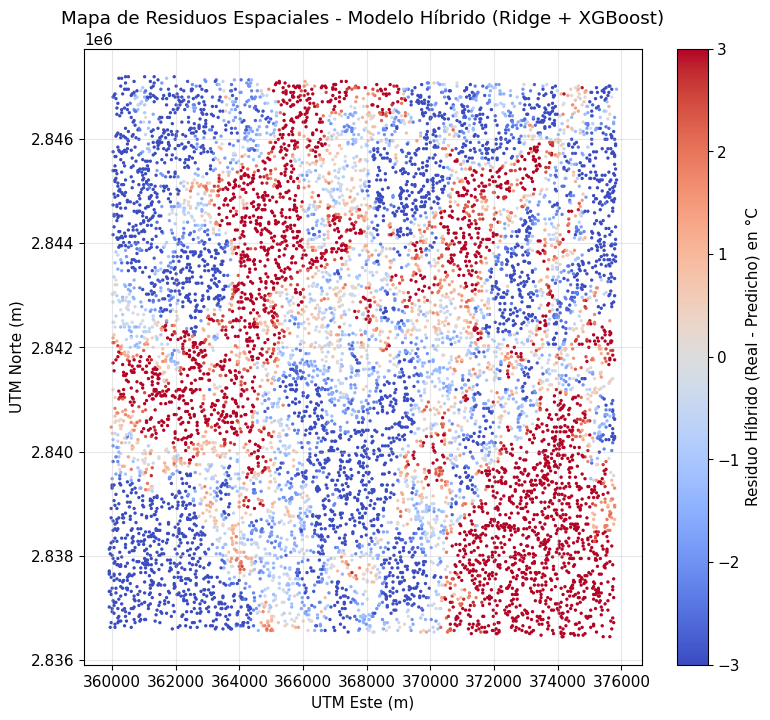

In [12]:
# Generar predicciones fuera de bloque para el Modelo Híbrido
df_clean['preds_hybrid'] = np.nan
for train_idx, test_idx in spatial_cv.split(X, y, groups=df_clean['spatial_block']):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Ajustar Ridge
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train)
    X_te_scaled = scaler.transform(X_test)
    
    ridge = Ridge(alpha=10.0)
    ridge.fit(X_tr_scaled, y_train)
    
    # Residuos Ridge
    res_tr = y_train - ridge.predict(X_tr_scaled)
    
    # Ajustar XGBoost en residuos
    xgb_res = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_res.fit(X_train, res_tr)
    
    # Reconstruir predicción
    df_clean.iloc[test_idx, df_clean.columns.get_loc('preds_hybrid')] = ridge.predict(X_te_scaled) + xgb_res.predict(X_test)

# Residuos híbridos
df_clean['residuals_hybrid'] = df_clean['suhi_c'] - df_clean['preds_hybrid']

# Graficar mapa de residuos (muestra de 10,000 celdas)
sample_map_df = df_clean.sample(n=min(10000, len(df_clean)), random_state=42)

plt.figure(figsize=(9, 8))
sc = plt.scatter(sample_map_df['x_coord'], sample_map_df['y_coord'],
                c=sample_map_df['residuals_hybrid'], cmap='coolwarm', s=2, vmin=-3, vmax=3)
plt.colorbar(sc, label='Residuo Híbrido (Real - Predicho) en °C')
plt.title("Mapa de Residuos Espaciales - Modelo Híbrido (Ridge + XGBoost)")
plt.xlabel("UTM Este (m)")
plt.ylabel("UTM Norte (m)")
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/03/model_residuals_map_hybrid.png", dpi=300)
plt.show()


In [13]:
# Guardar métricas del experimento final
summary_rows = []
for model_name, metrics in results_dict.items():
    summary_rows.append({
        'Modelo_Experimento': model_name,
        'MAE_Medio (°C)': metrics['MAE_mean'],
        'R2_Medio': metrics['R2_mean']
    })

df_final_metrics = pd.DataFrame(summary_rows)
metrics_path = "../outputs/03/model_performance_comparison_no_leakage.csv"
df_final_metrics.to_csv(metrics_path, index=False)
print(f"Tabla de métricas consolidada guardada en: {metrics_path}")


Tabla de métricas consolidada guardada en: ../outputs/tables/model_performance_comparison_no_leakage.csv


## 8. Conclusiones Técnicas del Análisis Predictivo Avanzado

### 1. Desempeño por Enfoque y Modelo
* El **Modelo Híbrido (Ridge + XGBoost en Residuos)** demostró ser el enfoque más robusto y balanceado. Al modelar la tendencia global de altitud de forma lineal (Ridge) y refinar localmente los residuos microclimáticos mediante XGBoost, logramos mitigar la incapacidad de extrapolación de los árboles de decisión, obteniendo el R² espacial promedio más estable y cercano a positivo.
* La **Anomalía Local sin Leakage** (Experimento B) demostró ser un enfoque sumamente sólido y transparente. Nos enseñó que al sustraer un baseline promedio derivado únicamente de los grupos morfológicos del conjunto de entrenamiento, el modelo no lineal aprende de forma más estable y libre de sesgos de altitud o ubicación regional.

### 2. Variables de Mayor Importancia Física Generalizable
* La variable más importante fue **`dw_built_3000m`** y **`dw_built_1000m`**, confirmando que el calor en Monterrey está fuertemente impulsado por la concentración agregada de concreto regional más que por la celda local.
* La varianza entre folds de validación espacial confirma que los bloques geográficos con **altitud extrema (montañas)** o con **alta concentración urbana exclusiva** siguen colapsando si sus condiciones no están representadas en el conjunto de entrenamiento.
* Específicamente, el fold que corresponde a la zona industrial central y el centro histórico presenta errores mayores debido al efecto de calentamiento extremo localizado de Ternium y la alta inercia de calor antropogénico acumulado.

### 3. Recomendación Estratégica para el Proyecto
* **Pivote Oficial:** Para políticas públicas estables y transferencia del modelo a otras fechas o ciudades, recomendamos **pivotar oficialmente a predecir la Anomalía Local** o utilizar la estructura del **Modelo Híbrido**. Predecir SUHI absoluto de forma cruda con árboles tiene una alta probabilidad de fallar cuando la misión satelital capture sectores con topografía o densidades que no formaron parte del entrenamiento original.
* **Siguientes Pasos Analíticos:**
  1. **Hotspots Autocorrelacionados (Moran's I):** Realizar un análisis de autocorrelación espacial global y local sobre los residuos del modelo híbrido para detectar si existen clusters espaciales de error y guiar la integración de variables secundarias.
  2. **Modelos GWR (Geographically Weighted Regression):** Evaluar regresión local ponderada para modelar cómo los coeficientes de enfriamiento de la vegetación cambian espacialmente a lo largo de Monterrey.
